# 35 - System II SBC Failure Diagnostic

Diagnoses the failed full-budget matched ongoing-degradation S-B posterior from `scripts/stage3_sysII_full_matched.py`.

Inputs:
- `results/stage3_sysII_matched_full_validation.json`
- `data/wu2003_sbi_train_sb_n03_matched_full.npz`
- `sbi-logs/wu2003_posterior_variant_matched_full_sb_seed*.pkl`

Questions:
1. Which parameters/seeds fail SBC?
2. Which summary dimensions have the heavy tails flagged by `sbi` z-scoring warnings?
3. How much posterior mass is outside the prior support when `reject_outside_prior=False` is used?
4. What should be tested next before another full-budget ensemble?

In [1]:
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy import stats as scipy_stats

cwd = pathlib.Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
import sys
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'scripts'))

from cstr_sbi.recycle.physics import PARAM_NAMES
from cstr_sbi.recycle.priors import PRIOR_LOW_5D, PRIOR_HIGH_5D, box_uniform_5d
from cstr_sbi.recycle.summaries import summary_names
from sbi_pipeline import _structure_config, _simulate_summary

DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
SBI_LOGS = ROOT / 'sbi-logs'
FIGURES = ROOT / 'figures'
for path in [RESULTS, FIGURES]:
    path.mkdir(exist_ok=True)

SUMMARY_JSON = RESULTS / 'stage3_sysII_matched_full_validation.json'
BANK_PATH = DATA / 'wu2003_sbi_train_sb_n03_matched_full.npz'
assert SUMMARY_JSON.exists(), SUMMARY_JSON
assert BANK_PATH.exists(), BANK_PATH

print(f'ROOT={ROOT}')
print(f'PARAM_NAMES={PARAM_NAMES}')
print(f'prior low ={PRIOR_LOW_5D}')
print(f'prior high={PRIOR_HIGH_5D}')

ROOT=/Users/simo/inso-po-RD/cstr-model-optimisation/research_project
PARAM_NAMES=['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']
prior low =[0.4 0.4 0.5 0.4 0.7]
prior high=[1.2  1.2  1.   1.2  0.95]


## 1. Full-budget SBC summary

The full run selected seed 3 only because it was the least bad seed at `N_SBC=400`; this cell tabulates the saved p-values and the independent `N_SBC=800` confirmation.

In [2]:
with open(SUMMARY_JSON) as f:
    full = json.load(f)

print('status:', full['status'])
print(f"elapsed={full['elapsed_wall_s']/3600:.2f} h, bank={full['bank_wall_s']/3600:.2f} h")
print(f"selected seed={full['selected_seed']}, N400 min KS={full['selected_min_ks_pvalue']:.3e}, N800 min KS={full['selected_confirmation_min_ks_pvalue']:.3e}")

seed_rows = []
for row in full['per_seed']:
    rec = {'seed': row['seed'], 'min_ks_pvalue': row['min_ks_pvalue']}
    for name in PARAM_NAMES:
        rec[f'{name}_ks_pvalue'] = row['sbc'][name]['ks_pvalue']
        rec[f'{name}_mean_rank_frac'] = row['sbc'][name]['mean_rank_frac']
    seed_rows.append(rec)
seed_df = pd.DataFrame(seed_rows).sort_values('min_ks_pvalue', ascending=False)
display(seed_df)
seed_df.to_csv(RESULTS / '35_sysII_matched_full_seed_sbc_summary.csv', index=False)

confirm = full['selected_confirmation_sbc']
confirm_df = pd.DataFrame([
    {
        'parameter': name,
        'ks_pvalue': confirm[name]['ks_pvalue'],
        'mean_rank_frac': confirm[name]['mean_rank_frac'],
    }
    for name in PARAM_NAMES
])
display(confirm_df)
confirm_df.to_csv(RESULTS / '35_sysII_matched_full_selected_seed_n800_sbc.csv', index=False)

status: complete
elapsed=18.37 h, bank=14.55 h
selected seed=3, N400 min KS=4.116e-04, N800 min KS=9.030e-08


,seed,min_ks_pvalue,alpha_ks_pvalue,alpha_mean_rank_frac,beta_r_ks_pvalue,beta_r_mean_rank_frac,eta_col_ks_pvalue,eta_col_mean_rank_frac,xi_reb_ks_pvalue,xi_reb_mean_rank_frac,z_A0_eff_ks_pvalue,z_A0_eff_mean_rank_frac
3,3,4.116115e-04,0.000619,0.550400,9.220330e-04,0.556113,4.116115e-04,0.551488,3.814607e-01,0.519238,0.021067,0.529162
7,7,2.708668e-04,0.853412,0.496713,2.708668e-04,0.552863,4.985745e-02,0.534837,9.220330e-04,0.449537,0.136559,0.528937
2,2,1.089165e-05,0.107771,0.529487,2.612124e-01,0.514975,4.116115e-04,0.446050,1.089165e-05,0.578588,0.028358,0.470575
6,6,4.656914e-07,0.002865,0.449675,1.764487e-04,0.452900,4.656914e-07,0.576412,1.549314e-02,0.523050,0.021067,0.466650
1,1,2.656868e-07,0.004098,0.539138,9.145085e-01,0.500825,2.656868e-07,0.569275,6.976615e-01,0.513200,0.000922,0.547100
5,5,3.790698e-14,0.958588,0.500688,1.127992e-02,0.475125,6.976615e-01,0.489138,3.790698e-14,0.623337,0.530890,0.492163
0,0,1.041525e-16,0.015493,0.457788,1.712818e-01,0.522325,3.779122e-02,0.519075,1.041525e-16,0.373900,0.002865,0.456325
4,4,3.421117e-21,0.996296,0.503100,1.376514e-08,0.410125,6.511749e-02,0.459813,3.421117e-21,0.336450,0.008130,0.466138


,parameter,ks_pvalue,mean_rank_frac
0,alpha,9.029578e-08,0.564925
1,beta_r,6.222775e-06,0.548887
2,eta_col,2.492272e-05,0.548531
3,xi_reb,1.893203e-02,0.530062
4,z_A0_eff,1.697694e-03,0.534044


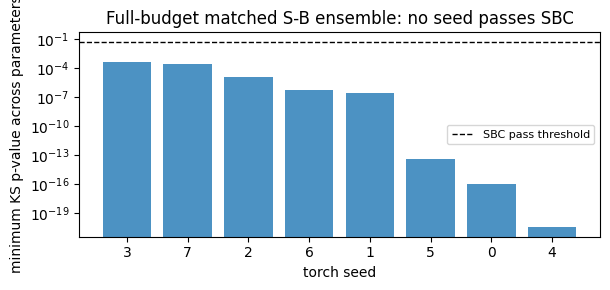

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.bar(seed_df['seed'].astype(str), seed_df['min_ks_pvalue'], color='tab:blue', alpha=0.8)
ax.axhline(0.05, color='k', lw=1.0, ls='--', label='SBC pass threshold')
ax.set_yscale('log')
ax.set_xlabel('torch seed')
ax.set_ylabel('minimum KS p-value across parameters')
ax.set_title('Full-budget matched S-B ensemble: no seed passes SBC')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / '35_sysII_matched_full_seed_min_ks.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. Training-bank summary outliers

`sbi` warned that many summary dimensions have extreme outliers beyond 10x IQR. This section identifies those dimensions in the matched full training bank and exports a ranked CSV.

In [4]:
bank = np.load(BANK_PATH)
theta_train = bank['thetas']
x_train = bank['summaries']
names = summary_names('S-B')
assert x_train.shape[1] == len(names), (x_train.shape, len(names))
print('bank theta:', theta_train.shape, 'summaries:', x_train.shape)

q1 = np.percentile(x_train, 25, axis=0)
q3 = np.percentile(x_train, 75, axis=0)
iqr = q3 - q1
median = np.median(x_train, axis=0)
iqr_safe = np.where(iqr > 0, iqr, np.nan)
robust_z = np.abs((x_train - median) / iqr_safe)
outlier_mask = robust_z > 10.0

out_rows = []
for j, name in enumerate(names):
    col = x_train[:, j]
    finite = np.isfinite(col)
    out_rows.append({
        'idx': j,
        'name': name,
        'finite_frac': float(finite.mean()),
        'median': float(np.nanmedian(col)),
        'iqr': float(iqr[j]),
        'min': float(np.nanmin(col)),
        'max': float(np.nanmax(col)),
        'outlier_frac_gt_10iqr': float(np.nanmean(outlier_mask[:, j])),
        'outlier_count_gt_10iqr': int(np.nansum(outlier_mask[:, j])),
        'abs_skew': float(abs(pd.Series(col).skew())),
        'kurtosis': float(pd.Series(col).kurtosis()),
    })
outlier_df = pd.DataFrame(out_rows).sort_values(['outlier_frac_gt_10iqr', 'kurtosis'], ascending=False)
display(outlier_df.head(25))
outlier_df.to_csv(RESULTS / '35_sysII_summary_outlier_diagnostics.csv', index=False)
print('features with >0 outliers:', int((outlier_df['outlier_count_gt_10iqr'] > 0).sum()), '/', len(outlier_df))
print('saved:', RESULTS / '35_sysII_summary_outlier_diagnostics.csv')

bank theta: (15000, 5) summaries: (15000, 66)


,idx,name,finite_frac,median,iqr,min,max,outlier_frac_gt_10iqr,outlier_count_gt_10iqr,abs_skew,kurtosis
48,48,V_norm_mean,1.0,0.405494,0.000210,0.393322,0.663379,0.222733,3341,2.062904,2.869014
53,53,V_norm_q_mean,1.0,0.405523,0.000408,0.389841,0.663431,0.220533,3308,2.062728,2.868419
52,52,V_norm_max,1.0,0.408149,0.001113,0.406826,0.667861,0.220133,3302,2.059281,2.855508
51,51,V_norm_min,1.0,0.403070,0.000802,0.387053,0.659557,0.216000,3240,2.066476,2.883497
61,61,Vn_final,1.0,0.405797,0.002285,0.389090,0.663206,0.208067,3121,2.062310,2.868760
15,15,Q_j_min,1.0,15.179176,1.049480,-12.471910,16.111879,0.094800,1422,2.726128,5.528383
1,1,T_r_std,1.0,0.717651,0.051574,0.549021,1.990700,0.007733,116,5.850796,47.308659
49,49,V_norm_std,1.0,0.001526,0.000229,0.001111,0.011884,0.005733,86,6.338565,74.928642
32,32,F_R_norm_slope,1.0,-0.000118,0.000733,-0.003039,0.031156,0.005133,77,8.936675,120.174202
50,50,V_norm_slope,1.0,0.000002,0.000343,-0.015498,0.005885,0.005067,76,11.808187,193.903839


features with >0 outliers: 18 / 66
saved: /Users/simo/inso-po-RD/cstr-model-optimisation/research_project/results/35_sysII_summary_outlier_diagnostics.csv


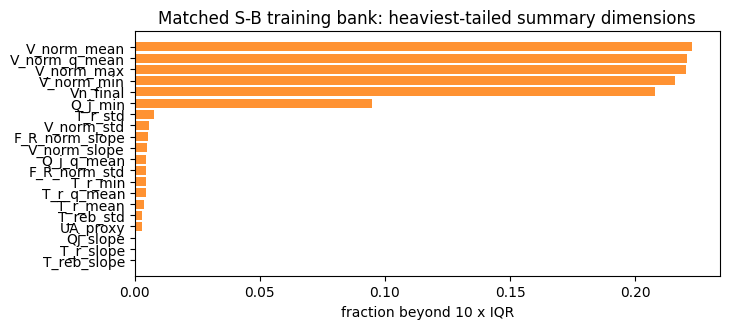

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
top = outlier_df.head(20).iloc[::-1]
ax.barh(top['name'], top['outlier_frac_gt_10iqr'], color='tab:orange', alpha=0.85)
ax.set_xlabel('fraction beyond 10 x IQR')
ax.set_title('Matched S-B training bank: heaviest-tailed summary dimensions')
fig.tight_layout()
fig.savefig(FIGURES / '35_sysII_summary_outlier_fraction.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Posterior support diagnostic

The full run used `reject_outside_prior=False` to avoid the known rejection-sampling hang. This cell regenerates a modest matched validation set once, evaluates all eight saved posteriors on the same summaries, and measures how much posterior mass falls outside the valid parameter box. It also recomputes ranks on this shared diagnostic set so support violations and rank skew can be compared directly.

In [6]:
N_DIAG = 40
N_POST_DIAG = 200
DIAG_SEED = 20260827
DIAG_SET_PATH = RESULTS / '35_sysII_matched_diag_set.npz'
torch.manual_seed(DIAG_SEED)
np_rng = np.random.default_rng(DIAG_SEED)
prior = box_uniform_5d()
ctrl, y0 = _structure_config('S-B')

if DIAG_SET_PATH.exists():
    diag = np.load(DIAG_SET_PATH)
    theta_diag = np.asarray(diag['theta'][:N_DIAG], dtype=np.float32)
    summary_diag = np.asarray(diag['summaries'][:N_DIAG], dtype=np.float32)
    print('loaded cached diag set:', theta_diag.shape, summary_diag.shape)
else:
    theta_diag, summary_diag = [], []
    t0 = time.time()
    while len(theta_diag) < N_DIAG:
        th = prior.sample((1,)).numpy()[0]
        s = _simulate_summary(th, ctrl, y0, 'S-B', 0.003, np_rng, scenario_specific_warm_start=True)
        if s is None:
            continue
        theta_diag.append(th)
        summary_diag.append(s)
        if len(theta_diag) % 10 == 0:
            print(f'generated {len(theta_diag)}/{N_DIAG} matched diagnostic summaries ({time.time()-t0:.0f}s)')
    theta_diag = np.asarray(theta_diag, dtype=np.float32)
    summary_diag = np.asarray(summary_diag, dtype=np.float32)
    np.savez(DIAG_SET_PATH, theta=theta_diag, summaries=summary_diag)
    print('generated diag set:', theta_diag.shape, summary_diag.shape, 'wall_s=', time.time()-t0)

generated 10/40 matched diagnostic summaries (68s)


generated 20/40 matched diagnostic summaries (132s)


generated 30/40 matched diagnostic summaries (196s)


generated 40/40 matched diagnostic summaries (209s)
generated diag set: (40, 5) (40, 66) wall_s= 209.12642312049866


In [7]:
support_rows = []
rank_rows = []
samples_dir = RESULTS / '35_support_samples'
samples_dir.mkdir(exist_ok=True)

for seed in range(8):
    pkl = SBI_LOGS / f'wu2003_posterior_variant_matched_full_sb_seed{seed}.pkl'
    with open(pkl, 'rb') as f:
        payload = pickle.load(f)
    posterior = payload['posterior']
    print(f'\nseed {seed}: sampling {N_DIAG} x {N_POST_DIAG}')
    seed_samples = []
    t_seed = time.time()
    for i, s in enumerate(summary_diag):
        with torch.no_grad():
            samp = posterior.sample(
                (N_POST_DIAG,),
                x=torch.tensor(s, dtype=torch.float32),
                show_progress_bars=False,
                reject_outside_prior=False,
            ).detach().cpu().numpy()
        seed_samples.append(samp)
        in_box = (samp >= PRIOR_LOW_5D) & (samp <= PRIOR_HIGH_5D)
        support_rows.append({
            'seed': seed,
            'draw': i,
            'overall_outside_frac': float((~in_box).any(axis=1).mean()),
            **{f'{name}_below_frac': float((samp[:, k] < PRIOR_LOW_5D[k]).mean()) for k, name in enumerate(PARAM_NAMES)},
            **{f'{name}_above_frac': float((samp[:, k] > PRIOR_HIGH_5D[k]).mean()) for k, name in enumerate(PARAM_NAMES)},
        })
        for k, name in enumerate(PARAM_NAMES):
            rank_rows.append({
                'seed': seed,
                'draw': i,
                'parameter': name,
                'rank_frac': float((samp[:, k] < theta_diag[i, k]).mean()),
                'truth': float(theta_diag[i, k]),
                'sample_mean': float(np.mean(samp[:, k])),
                'sample_sd': float(np.std(samp[:, k])),
            })
    seed_samples = np.asarray(seed_samples, dtype=np.float32)
    np.save(samples_dir / f'seed{seed}_samples.npy', seed_samples)
    print(f'seed {seed} done in {time.time()-t_seed:.0f}s; samples={seed_samples.shape}')

support_df = pd.DataFrame(support_rows)
rank_df = pd.DataFrame(rank_rows)
support_df.to_csv(RESULTS / '35_sysII_posterior_support_by_draw.csv', index=False)
rank_df.to_csv(RESULTS / '35_sysII_rank_skew_by_draw.csv', index=False)
display(support_df.groupby('seed')['overall_outside_frac'].describe())
display(rank_df.groupby(['seed', 'parameter'])['rank_frac'].mean().unstack())


seed 0: sampling 40 x 200


/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 10.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 35.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 24.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(


/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 9.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 63.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 5.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 26.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(


seed 0 done in 1s; samples=(40, 200, 5)

seed 1: sampling 40 x 200


/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 31.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 7.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 72.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(


...

seed 6 done in 0s; samples=(40, 200, 5)

seed 7: sampling 40 x 200


/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 8.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 49.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(
/Users/simo/.vscode/tmp/tmp_vscode_1/ipykernel_71604/2786182964.py:16: UserWarning: 11.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = posterior.sample(


seed 7 done in 0s; samples=(40, 200, 5)


,count,mean,std,min,25%,50%,75%,max
seed,,,,,,,,
0,40.0,0.039125,0.118548,0.0,0.0,0.0,0.00625,0.635
1,40.0,0.040250,0.127510,0.0,0.0,0.0,0.01125,0.720
2,40.0,0.041125,0.099676,0.0,0.0,0.0,0.01875,0.455
3,40.0,0.044125,0.135106,0.0,0.0,0.0,0.01125,0.605
4,40.0,0.035375,0.085585,0.0,0.0,0.0,0.02500,0.325
5,40.0,0.049625,0.134438,0.0,0.0,0.0,0.02625,0.645
6,40.0,0.032000,0.094637,0.0,0.0,0.0,0.01000,0.465
7,40.0,0.035125,0.094845,0.0,0.0,0.0,0.02125,0.490


parameter,alpha,beta_r,eta_col,xi_reb,z_A0_eff
seed,,,,,
0,0.523250,0.543000,0.518750,0.376875,0.533250
1,0.585375,0.566375,0.605625,0.472625,0.591125
2,0.587875,0.561750,0.478375,0.523250,0.559125
3,0.645250,0.639750,0.596375,0.543250,0.573250
4,0.560750,0.463500,0.500625,0.281125,0.485625
5,0.598875,0.534375,0.535625,0.621250,0.549625
6,0.520875,0.521625,0.555875,0.501250,0.508750
7,0.574750,0.625750,0.580375,0.453000,0.590625


In [8]:
support_summary_rows = []
for seed, g in support_df.groupby('seed'):
    rec = {
        'seed': seed,
        'overall_outside_mean': g['overall_outside_frac'].mean(),
        'overall_outside_median': g['overall_outside_frac'].median(),
        'overall_outside_p95': g['overall_outside_frac'].quantile(0.95),
    }
    for name in PARAM_NAMES:
        rec[f'{name}_below_mean'] = g[f'{name}_below_frac'].mean()
        rec[f'{name}_above_mean'] = g[f'{name}_above_frac'].mean()
    support_summary_rows.append(rec)
support_summary = pd.DataFrame(support_summary_rows).sort_values('overall_outside_mean', ascending=False)
display(support_summary)
support_summary.to_csv(RESULTS / '35_sysII_posterior_support_summary.csv', index=False)

rank_summary = (rank_df.groupby(['seed', 'parameter'])['rank_frac']
                .agg(['mean', 'std'])
                .reset_index())
rank_summary.to_csv(RESULTS / '35_sysII_rank_skew_summary.csv', index=False)
display(rank_summary)

,seed,overall_outside_mean,overall_outside_median,overall_outside_p95,alpha_below_mean,alpha_above_mean,beta_r_below_mean,beta_r_above_mean,eta_col_below_mean,eta_col_above_mean,xi_reb_below_mean,xi_reb_above_mean,z_A0_eff_below_mean,z_A0_eff_above_mean
5,5,0.049625,0.0,0.28675,0.016125,0.000750,0.002875,0.001000,0.000000,0.002750,0.001875,0.000125,0.015000,0.009625
3,3,0.044125,0.0,0.43700,0.015125,0.000625,0.011750,0.000875,0.000000,0.000250,0.000000,0.000250,0.012625,0.003250
2,2,0.041125,0.0,0.27300,0.011375,0.000625,0.005000,0.001125,0.000000,0.008250,0.000000,0.000500,0.009375,0.005125
1,1,0.040250,0.0,0.26275,0.018000,0.000250,0.005750,0.000500,0.000000,0.001000,0.000250,0.001875,0.010000,0.002750
0,0,0.039125,0.0,0.24575,0.015875,0.000125,0.008875,0.000375,0.000000,0.000500,0.000000,0.002375,0.009375,0.001750
4,4,0.035375,0.0,0.30050,0.007750,0.000125,0.007500,0.001000,0.000125,0.000625,0.000000,0.008125,0.002250,0.008000
7,7,0.035125,0.0,0.16375,0.012250,0.000250,0.004000,0.000250,0.000000,0.003125,0.000375,0.008250,0.004250,0.002625
6,6,0.032000,0.0,0.15625,0.011625,0.002125,0.009000,0.000500,0.000125,0.001750,0.000000,0.000000,0.004375,0.003250


,seed,parameter,mean,std
0,0,alpha,0.523250,0.329573
1,0,beta_r,0.543000,0.274371
2,0,eta_col,0.518750,0.273000
3,0,xi_reb,0.376875,0.276414
4,0,z_A0_eff,0.533250,0.327290
5,1,alpha,0.585375,0.304510
6,1,beta_r,0.566375,0.292270
7,1,eta_col,0.605625,0.297350
8,1,xi_reb,0.472625,0.277697
9,1,z_A0_eff,0.591125,0.316417


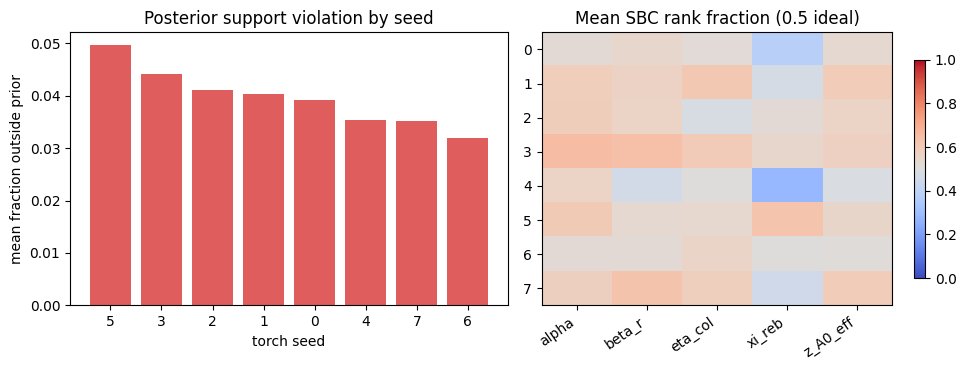

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(support_summary['seed'].astype(str), support_summary['overall_outside_mean'], color='tab:red', alpha=0.75)
axes[0].set_xlabel('torch seed')
axes[0].set_ylabel('mean fraction outside prior')
axes[0].set_title('Posterior support violation by seed')

rank_pivot = rank_summary.pivot(index='seed', columns='parameter', values='mean').loc[:, PARAM_NAMES]
im = axes[1].imshow(rank_pivot.values, vmin=0, vmax=1, cmap='coolwarm', aspect='auto')
axes[1].set_xticks(range(len(PARAM_NAMES)))
axes[1].set_xticklabels(PARAM_NAMES, rotation=35, ha='right')
axes[1].set_yticks(range(len(rank_pivot.index)))
axes[1].set_yticklabels(rank_pivot.index)
axes[1].set_title('Mean SBC rank fraction (0.5 ideal)')
fig.colorbar(im, ax=axes[1], shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES / '35_sysII_support_and_rank_diagnostic.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Interpretation and next experiments

The full-budget run did not fail because of insufficient training budget alone: increasing from the reduced diagnostic to 15,000 simulations and eight seeds did not produce a calibrated posterior. The likely failure modes to test next are:

1. **Summary scaling/heavy tails:** many handcrafted summary dimensions have extreme outliers before z-scoring. Test robust scaling, log/softplus transforms for strictly positive heavy-tailed summaries, or clipping/winsorisation based only on the training bank.
2. **Prior support mismatch:** posterior samples frequently leave the valid parameter box when `reject_outside_prior=False`. Test a support-aware parameterisation, such as training in unconstrained logit space and mapping back to physical bounds, or a posterior estimator with bounded support.
3. **Prior/domain tension:** verify that the matched prior range is physically stable and manuscript-consistent. In particular, the code prior currently permits `eta_col` down to 0.50, while the manuscript scenario table uses 0.80 as the stable lower bound for the curated scenarios.
4. **Architecture/preprocessing interaction:** repeat only reduced-budget diagnostics first; do not rerun another full 15k x 8-seed ensemble until one reduced diagnostic passes SBC and has acceptable support behaviour.

Recommended next notebook/script: build a reduced-budget comparison over preprocessing variants on the existing simulator: baseline z-score, no x z-score, robust-scaled summaries, and transformed/clipped problematic features. Use the same matched SBC test set for all variants and choose by both min-KS and posterior support violation rate.